In [111]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [49]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [50]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [51]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
df.drop(columns=['SibSp', 'Parch', 'Ticket', 'PassengerId', 'Cabin', 'Name'], inplace=True)

In [53]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [59]:
df.columns[df.isnull().any()]

Index(['Age', 'Embarked'], dtype='object')

In [61]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

Survived    0    1
Sex               
female     81  233
male      468  109


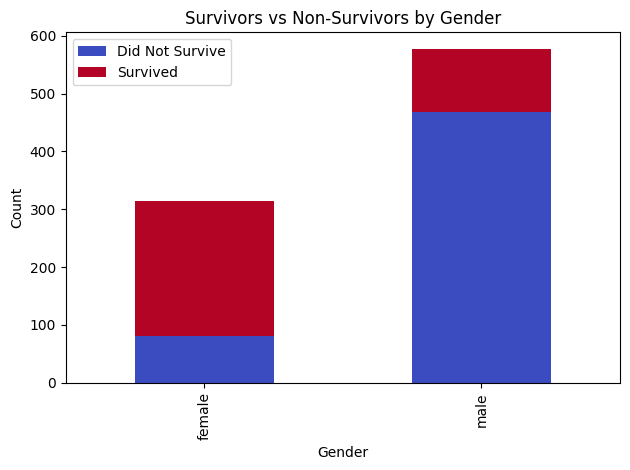

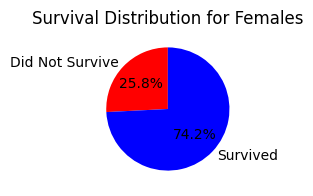

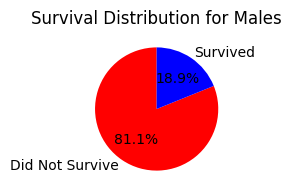

In [100]:
gender_survival = df.groupby(['Sex', 'Survived']).size().unstack()
print(gender_survival)
plt.Figure(figsize=(5,4))
gender_survival.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Survivors vs Non-Survivors by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()


for gender in gender_survival.index:
    plt.figure(figsize=(2,2))
    plt.pie(gender_survival.loc[gender], 
            labels=['Did Not Survive', 'Survived'], 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=['red', 'blue'])
    plt.title(f'Survival Distribution for {gender.capitalize()}s')
    plt.show()

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


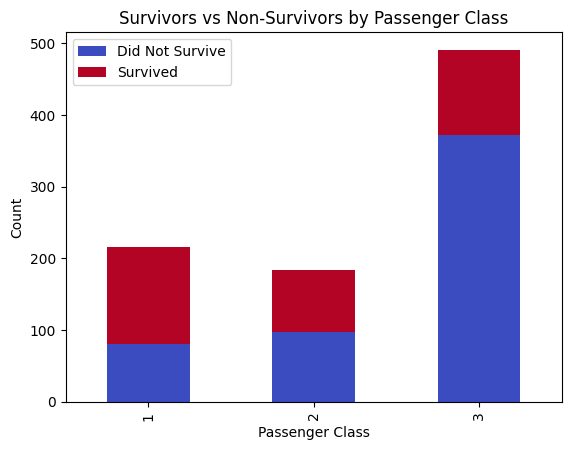

In [81]:
Pclass_survival = df.groupby(['Pclass', 'Survived']).size().unstack()
print(Pclass_survival)
Pclass_survival.plot(kind='bar',stacked=True,colormap='coolwarm')
plt.title('Survivors vs Non-Survivors by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

In [77]:
def age_group(age):
    if age < 12:
        return 'Child'
    elif age < 60:
        return 'Adult'
    else:
        return 'Elderly'

df['AgeGroup'] = df['Age'].apply(age_group)


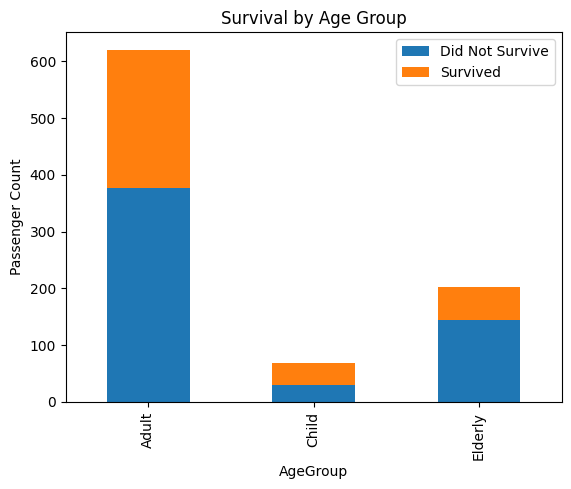

In [ ]:
agegroup_survival = df.groupby(['AgeGroup', 'Survived']).size().unstack()
agegroup_survival.plot(kind='bar', stacked=True)
plt.title('Survival by Age Group')
plt.ylabel('Passenger Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

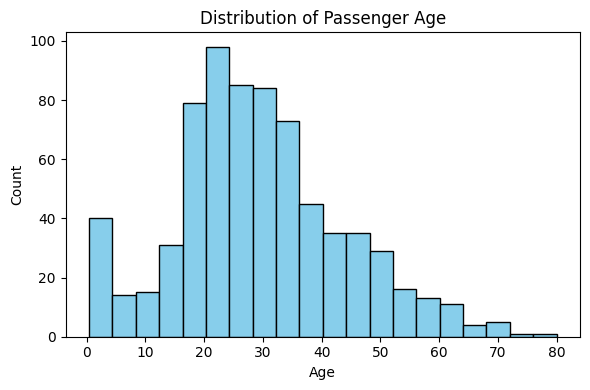

In [102]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


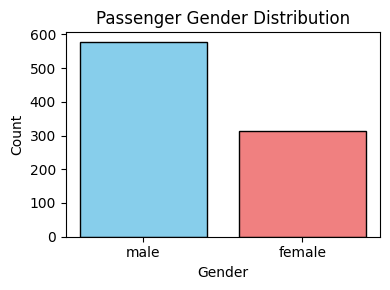

In [105]:
gender_counts = df['Sex'].value_counts()

plt.figure(figsize=(4, 3))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'lightcoral'], edgecolor='black')
plt.title('Passenger Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



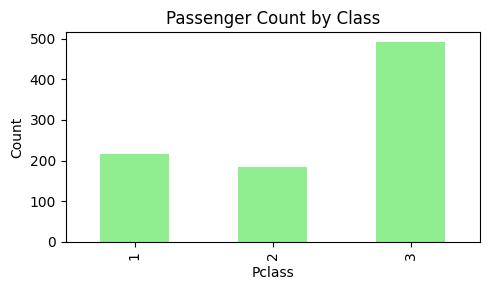

In [106]:
plt.figure(figsize=(5, 3))
Pclass_counts = df['Pclass'].value_counts().sort_index()
Pclass_counts.plot(kind='bar', color='lightgreen')
plt.title('Passenger Count by Class')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

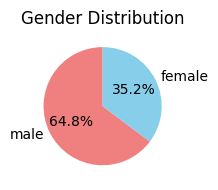

In [108]:
plt.figure(figsize=(3,2))
df['Sex'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

C:\Users\aryan verma\AppData\Local\Temp\ipykernel_3900\445110532.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')


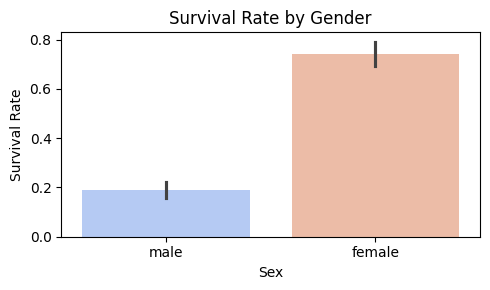

In [115]:
plt.figure(figsize=(5, 3))
sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

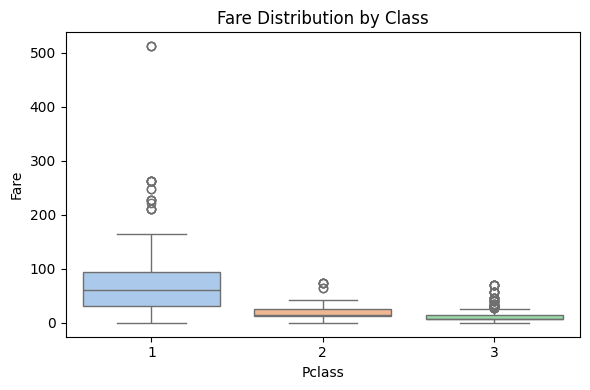

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Pclass', y='Fare', data=df, hue='Pclass', palette='pastel', legend=False)
plt.title('Fare Distribution by Class')
plt.tight_layout()
plt.show()